# LC RT × Spike Count OLS + Registry Comparison

Minimal pipeline:
1. Load & filter ephys data
2. Build per-trial spike counts (two windows)
3. OLS: spike_count ~ RT and baseline_spike_count ~ RT
4. Register OLS results + Sue encoding table in `PerUnitStatsRegistry`
5. Compare RT encoding to Q-chosen and outcome encoding

## 1. Imports & data loading

In [21]:
%matplotlib inline

import os, re, pickle, json
from pathlib import Path
from typing import Sequence, Optional, Tuple, Dict, Union, List
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams["svg.fonttype"] = "none"
from scipy.stats import spearmanr, wilcoxon, binomtest
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

from aind_dynamic_foraging_behavior_video_analysis.kinematics.tongue_analysis import (
    get_session_name_from_path,
    session_already_done,
)
from aind_dynamic_foraging_behavior_video_analysis.kinematics.tongue_kinematics_utils import (
    annotate_movement_timing,
    add_lick_metadata_to_movements,
)
from aind_dynamic_foraging_behavior_video_analysis.ephys.tongue_ephys import (
    get_events_dict,
    build_event_df,
    RasterPlotter,
    find_session_dir,
    load_intermediate_data,
    get_session_prefix,
)

In [2]:
with open('/root/capsule/scratch/combined_unit_tbl.pkl', 'rb') as file:
    combined_ephys_data = pickle.load(file)

In [3]:
COVERAGE_MIN = 90.0
DURATION50_MIN = 0.06  # seconds

base_dirs = [Path("/root/capsule/scratch/session_analysis_mlk")]

rows_pass = []
for base_dir in base_dirs:
    if not base_dir.exists():
        continue
    for subdir in base_dir.iterdir():
        if not (subdir.is_dir() and session_already_done(subdir)):
            continue
        json_file = subdir / "tongue_quality_stats.json"
        try:
            with open(json_file, "r") as f:
                d = json.load(f)
        except Exception:
            continue

        cov = float(d.get("coverage_pct", 0.0))
        dur50 = float(d.get("percentiles", {}).get("duration", {}).get("0.5", 0.0))

        if cov > COVERAGE_MIN and dur50 > DURATION50_MIN:
            rows_pass.append({
                "session_path": subdir,
                "session_id": d.get("session_id", subdir.name),
                "coverage_pct": cov,
                "duration_p50": dur50,
            })

filtered_df = pd.DataFrame(rows_pass)
filtered_session_paths = filtered_df["session_path"].tolist()
print(f"Sessions passing quality filter: {len(filtered_df)}")

Sessions passing quality filter: 44


In [4]:
DEFAULT_CRITERIA = {
    "isi_violations": {"bounds": [0.0, 0.1]},
    "p_max":         {"bounds": [0.5, 1.0]},
    "lat_max_p":     {"bounds": [0.005, 0.02]},
    "eu":            {"bounds": [0.0, 0.25]},
    "corr":          {"bounds": [0.95, 1.0]},
    "qc_pass":       {"items":  [True]},
    "peak":          {"bounds": [-1000, 0]},
    "trial_count":   {"bounds": [100, 2000]},
    "in_df":         {"items":  [True]},
}

def filter_by_criteria(df, criteria=None):
    if criteria is None:
        criteria = DEFAULT_CRITERIA
    mask = pd.Series(True, index=df.index)
    for col, rule in criteria.items():
        if "bounds" in rule:
            lo, hi = rule["bounds"]
            mask &= df[col].between(lo, hi, inclusive="both")
        if "items" in rule:
            mask &= df[col].isin(rule["items"])
    return df.loc[mask].copy()

session_order_full = [get_session_name_from_path(str(p)) for p in filtered_session_paths]
session_prefix_allow = set(get_session_prefix(s) for s in session_order_full)

combined_ephys_data = combined_ephys_data.copy()
combined_ephys_data["session_prefix"] = combined_ephys_data["session"].map(get_session_prefix)

criteria_filtered = filter_by_criteria(combined_ephys_data, DEFAULT_CRITERIA)
filtered_ephys = criteria_filtered.loc[
    criteria_filtered["session_prefix"].isin(session_prefix_allow)
].copy()

print(f"Filtered units: {len(filtered_ephys)} / {len(combined_ephys_data)}")

Filtered units: 104 / 18300


In [5]:
ROOT_SCRATCH = "/root/capsule/data/LC-NE_scratch_data_1"

def get_animal_id(session):
    m = re.match(r'^behavior_(\d+)_', session)
    if not m:
        raise ValueError(f"Cannot parse animal id from session: {session}")
    return m.group(1)

def find_summary_pkl(root, session):
    animal = get_animal_id(session)
    exact = Path(root) / animal / session / "ephys" / "opto" / "curated" / f"{session}_curated_soma_opto_tagging_summary.pkl"
    if exact.exists():
        return exact
    pref = get_session_prefix(session)
    candidates = list((Path(root) / animal).glob(
        f"{pref}_*/ephys/opto/curated/*_curated_soma_opto_tagging_summary.pkl"
    ))
    return candidates[0] if candidates else None

units_with_spikes = []
for session, subdf in filtered_ephys.groupby("session"):
    pkl_path = find_summary_pkl(ROOT_SCRATCH, session)
    if pkl_path is None:
        print(f"[skip] {session}")
        continue
    with open(pkl_path, "rb") as f:
        ephys_session_data = pickle.load(f)
    if not isinstance(ephys_session_data, pd.DataFrame):
        try:
            ephys_session_data = pd.DataFrame(ephys_session_data)
        except Exception:
            continue
    unit_ids = subdf["unit"].unique()
    ephys_data = (
        ephys_session_data[ephys_session_data["unit_id"].isin(unit_ids)]
        .copy()
        .assign(session=session)
    )
    print(f"[ok] {session}: {len(ephys_data)}/{len(unit_ids)} units")
    units_with_spikes.append(ephys_data)

units_with_spikes = (
    pd.concat(units_with_spikes, ignore_index=True)
    if units_with_spikes else pd.DataFrame(columns=["session","unit_id","spike_times"])
)
print("units_with_spikes shape:", units_with_spikes.shape)

[ok] behavior_716325_2024-05-31_10-31-14: 3/3 units
[ok] behavior_751004_2024-12-20_13-26-11: 3/3 units
[ok] behavior_751004_2024-12-21_13-28-28: 3/4 units
[ok] behavior_751004_2024-12-22_13-09-17: 1/1 units
[ok] behavior_751004_2024-12-23_14-20-03: 2/2 units
[ok] behavior_751181_2025-02-25_12-12-35: 2/2 units
[ok] behavior_751181_2025-02-27_11-24-47: 5/5 units
[ok] behavior_751766_2025-02-11_11-53-38: 5/5 units
[ok] behavior_751766_2025-02-13_11-31-21: 3/3 units
[ok] behavior_751766_2025-02-14_11-37-11: 4/4 units
[ok] behavior_751769_2025-01-16_11-32-05: 1/1 units
[ok] behavior_751769_2025-01-17_11-37-39: 3/3 units
[ok] behavior_751769_2025-01-18_10-15-25: 5/5 units
[ok] behavior_752014_2025-03-26_11-18-57: 1/1 units
[ok] behavior_752014_2025-03-28_11-04-59: 1/1 units
[ok] behavior_754897_2025-03-12_12-23-15: 3/3 units
[ok] behavior_754897_2025-03-14_11-28-53: 5/5 units
[ok] behavior_758017_2025-02-05_11-42-34: 2/2 units
[ok] behavior_758017_2025-02-06_11-26-14: 1/1 units
[ok] behavio

## 2. Analysis config & spike count extraction

In [6]:
@dataclass
class AnalysisConfig:
    align_key: str = "goCue"
    count_window_s: Tuple[float, float] = (0.0, 0.100)
    min_trials_per_group: int = 8
    only_cue_response_trials: bool = True
    latency_window_s: Optional[Tuple[float, float]] = None
    baseline_window_s: Optional[Tuple[float, float]] = None


def count_spikes_in_window(spike_times_sorted, t0, window):
    a, b = t0 + window[0], t0 + window[1]
    if not np.isfinite(a) or not np.isfinite(b):
        return 0
    i0 = np.searchsorted(spike_times_sorted, a, side="left")
    i1 = np.searchsorted(spike_times_sorted, b, side="left")
    return int(i1 - i0)


def first_spike_latency_in_window(spike_times_sorted, t0, window):
    a, b = t0 + window[0], t0 + window[1]
    if not np.isfinite(a) or not np.isfinite(b):
        return np.nan, False
    i0 = np.searchsorted(spike_times_sorted, a, side="left")
    i1 = np.searchsorted(spike_times_sorted, b, side="left")
    if i0 < i1:
        return float(spike_times_sorted[i0] - t0), True
    return np.nan, False


def build_trial_features(movs, licks, df_trials):
    tm = movs.copy()
    required_cols = {
        "cue_response_movement_number",
        "movement_latency_from_go",
        "movement_number_in_trial",
        "cue_response",
    }
    missing = required_cols - set(tm.columns)
    if missing:
        raise ValueError(f"movs missing required columns {missing}")

    crmn = tm.groupby("trial")["cue_response_movement_number"].first().astype("Int64")
    rt_first = tm.groupby("trial")["movement_latency_from_go"].min()

    if "cue_response" in tm.columns:
        rt_cr = (
            tm.loc[tm["cue_response"] == True]
              .groupby("trial")["movement_latency_from_go"]
              .first()
        )
    else:
        rt_cr = pd.Series(dtype=float)

    out = pd.DataFrame({
        "cue_response_movement_number": crmn,
        "reaction_time_firstmove": rt_first,
        "reaction_time_cueresponse": rt_cr,
    })

    kcols = ["peak_velocity", "duration", "excursion_angle_deg", "endpoint_x", "endpoint_y",
             "out_duration", "out_peak_velocity", "out_mean_velocity", "out_total_distance"]

    first_moves = (
        tm.loc[tm["movement_number_in_trial"] == 1, ["trial", *kcols]]
          .drop_duplicates("trial", keep="first")
          .set_index("trial")
          .rename(columns={c: f"first_move_{c}" for c in kcols})
    )
    cue_resp_moves = (
        tm.loc[tm["cue_response"] == True, ["trial", *kcols]]
          .drop_duplicates("trial", keep="first")
          .set_index("trial")
          .rename(columns={c: f"cue_response_{c}" for c in kcols})
    )
    out = out.join(first_moves, how="left").join(cue_resp_moves, how="left").sort_index()
    return out


def make_session_bundle(session, cfg):
    sdir = find_session_dir(session, roots=base_dirs)
    data = load_intermediate_data(sdir)
    movs, trials, licks, kins, evnts = data["movs"], data["trials"], data["licks"], data["kins"], data["events"]
    session_offset = evnts[evnts['event'] == 'goCue_start_time']['raw_timestamps'].iloc[0]

    events_dict = get_events_dict(trials, licks, kins)
    E = build_event_df(events_dict)
    Ev = E.dropna(subset=[cfg.align_key])
    align_times = Ev[cfg.align_key].astype(float)
    trial_features = build_trial_features(movs, licks, trials)

    if cfg.only_cue_response_trials:
        cr_trials = trial_features.index[trial_features["cue_response_movement_number"].notna()]
        keep = align_times.index.intersection(cr_trials)
        align_times = align_times.loc[keep]
        trial_features = trial_features.loc[keep]

    return {
        "session": session,
        "align_times": align_times,
        "trial_features": trial_features,
        "session_offset": session_offset,
    }


def analyze_unit_for_session(unit_row, bundle, cfg):
    session = bundle["session"]
    unit_id = unit_row["unit_id"]
    spikes = np.asarray(unit_row["spike_times"], dtype=float) - bundle["session_offset"]

    t0_map = bundle["align_times"].to_dict()
    win_count = cfg.count_window_s
    win_base = cfg.baseline_window_s
    win_lat = cfg.latency_window_s if cfg.latency_window_s is not None else cfg.count_window_s

    dur = win_count[1] - win_count[0]
    dur_b = win_base[1] - win_base[0] if win_base is not None else np.nan

    recs = []
    for tr in bundle["align_times"].index:
        t0 = t0_map.get(tr, np.nan)
        if not np.isfinite(t0):
            continue
        n = count_spikes_in_window(spikes, t0, win_count)
        n_base = count_spikes_in_window(spikes, t0, win_base) if win_base else np.nan
        fsl, had = first_spike_latency_in_window(spikes, t0, win_lat)
        recs.append({
            "unit_id": unit_id, "session": session, "trial": int(tr),
            "spike_count": int(n),
            "spike_rate_hz": (n / dur) if dur > 0 else np.nan,
            "baseline_spike_count": n_base,
            "baseline_spike_rate_hz": (n_base / dur_b) if dur_b > 0 else np.nan,
            "first_spike_latency_s": fsl,
        })
    unit_counts = pd.DataFrame(recs).set_index("trial")
    unit_counts = unit_counts.join(bundle["trial_features"], how="left").reset_index()
    return unit_counts

In [7]:
cfg = AnalysisConfig(
    align_key="goCue",
    count_window_s=(0.0, 0.2),
    baseline_window_s=(-1, 0.0),
    min_trials_per_group=20,
)
bundle_cache: Dict[str, dict] = {}
all_counts = []

for u in units_with_spikes.itertuples(index=False):
    session = u.session
    if session not in bundle_cache:
        bundle_cache[session] = make_session_bundle(session, cfg)
    unit_counts = analyze_unit_for_session(
        pd.Series(u._asdict()), bundle_cache[session], cfg
    )
    all_counts.append(unit_counts)

all_counts_df = pd.concat(all_counts, ignore_index=True).sort_values(
    ["session", "unit_id", "trial"]
)
print("all_counts_df shape:", all_counts_df.shape)
print("Columns:", all_counts_df.columns.tolist())

all_counts_df shape: (31993, 29)
Columns: ['trial', 'unit_id', 'session', 'spike_count', 'spike_rate_hz', 'baseline_spike_count', 'baseline_spike_rate_hz', 'first_spike_latency_s', 'cue_response_movement_number', 'reaction_time_firstmove', 'reaction_time_cueresponse', 'first_move_peak_velocity', 'first_move_duration', 'first_move_excursion_angle_deg', 'first_move_endpoint_x', 'first_move_endpoint_y', 'first_move_out_duration', 'first_move_out_peak_velocity', 'first_move_out_mean_velocity', 'first_move_out_total_distance', 'cue_response_peak_velocity', 'cue_response_duration', 'cue_response_excursion_angle_deg', 'cue_response_endpoint_x', 'cue_response_endpoint_y', 'cue_response_out_duration', 'cue_response_out_peak_velocity', 'cue_response_out_mean_velocity', 'cue_response_out_total_distance']


## 3. OLS: spike count ~ RT (response & baseline windows)

Fit OLS regressions independently from Sue's encoding table.
Both are registered separately in the registry.

In [8]:
def fit_rt_ols_per_unit(
    *,
    all_counts_df,
    get_session_prefix,
    rt_col="reaction_time_firstmove",
    count_col="spike_count",
    baseline_col="baseline_spike_count",
    unit_col_counts="unit_id",
    session_col_counts="session",
    min_trials=50,
    alpha=0.05,
    log_rt=True,
    zscore_rt=True,
):
    """
    Per-(session_prefix, unit) OLS regressions:
        count_col    ~ 1 + RT
        baseline_col ~ 1 + RT

    Returns a single DataFrame (rt_models) with columns:
        session_prefix, unit,
        n_trials, coef_rt, T_rt, p_rt, q_rt,
        n_trials_bl, coef_rt_bl, T_rt_bl, p_rt_bl, q_rt_bl
    """

    def canon_unit(x):
        try:
            return str(int(float(x)))
        except Exception:
            return str(x)

    def add_keys(df, session_col, unit_col):
        out = df.copy()
        out[session_col] = out[session_col].astype(str)
        out[unit_col] = out[unit_col].map(canon_unit)
        out["session_prefix"] = out[session_col].map(get_session_prefix).astype(str)
        out["unit"] = out[unit_col].astype(str)
        return out

    def _fit_per_key(counts, y_col, *, suffix):
        rows = []
        for (sp, u), g in counts.groupby(["session_prefix", "unit"]):
            g = g.dropna(subset=[rt_col, y_col])
            rt = g[rt_col].to_numpy(dtype=float)
            y = g[y_col].to_numpy(dtype=float)

            if log_rt:
                m = np.isfinite(rt) & (rt > 0) & np.isfinite(y)
            else:
                m = np.isfinite(rt) & np.isfinite(y)
            rt, y = rt[m], y[m]
            n = int(rt.size)

            if n < min_trials or np.nanstd(rt) == 0 or np.nanstd(y) == 0:
                rows.append({"session_prefix": sp, "unit": u, "n_trials": n,
                             f"coef_{suffix}": np.nan, f"T_{suffix}": np.nan, f"p_{suffix}": np.nan})
                continue

            x = np.log(rt) if log_rt else rt
            if zscore_rt:
                x = (x - np.nanmean(x)) / np.nanstd(x)

            X = sm.add_constant(x)
            try:
                res = sm.OLS(y, X).fit()
                rows.append({
                    "session_prefix": sp, "unit": u, "n_trials": n,
                    f"coef_{suffix}": float(res.params[1]),
                    f"T_{suffix}": float(res.tvalues[1]),
                    f"p_{suffix}": float(res.pvalues[1]),
                })
            except Exception:
                rows.append({"session_prefix": sp, "unit": u, "n_trials": n,
                             f"coef_{suffix}": np.nan, f"T_{suffix}": np.nan, f"p_{suffix}": np.nan})

        out = pd.DataFrame(rows).reset_index(drop=True)
        out[f"q_{suffix}"] = np.nan
        m = out[f"p_{suffix}"].notna()
        if m.any():
            _, q, _, _ = multipletests(out.loc[m, f"p_{suffix}"].values, alpha=alpha, method="fdr_bh")
            out.loc[m, f"q_{suffix}"] = q
        return out

    # --- Counts table ---
    counts = add_keys(all_counts_df, session_col_counts, unit_col_counts)

    # --- Fit two RT models ---
    rt_main = _fit_per_key(counts, count_col, suffix="rt")
    rt_base = _fit_per_key(counts, baseline_col, suffix="rt_bl")

    rt_models = rt_main.merge(rt_base, on=["session_prefix", "unit"], how="outer", validate="one_to_one")
    rt_models = rt_models.rename(columns={"n_trials_x": "n_trials", "n_trials_y": "n_trials_bl"})
    rt_models = rt_models[[
        "session_prefix", "unit",
        "n_trials", "coef_rt", "T_rt", "p_rt", "q_rt",
        "n_trials_bl", "coef_rt_bl", "T_rt_bl", "p_rt_bl", "q_rt_bl",
    ]]

    print(f"RT models: {len(rt_models)} units")
    print(f"  response window: {rt_models['T_rt'].notna().sum()} valid")
    print(f"  baseline window: {rt_models['T_rt_bl'].notna().sum()} valid")

    return rt_models

In [9]:
# Fit OLS regressions (independent of Sue)
rt_models = fit_rt_ols_per_unit(
    all_counts_df=all_counts_df,
    get_session_prefix=get_session_prefix,
    rt_col="reaction_time_firstmove",
    count_col="spike_count",
    baseline_col="baseline_spike_count",
    unit_col_counts="unit_id",
    session_col_counts="session",
    min_trials=50,
    alpha=0.05,
    log_rt=True,
    zscore_rt=True,
)
rt_models.head(10)

RT models: 103 units
  response window: 103 valid
  baseline window: 103 valid


,session_prefix,unit,n_trials,coef_rt,T_rt,p_rt,q_rt,n_trials_bl,coef_rt_bl,T_rt_bl,p_rt_bl,q_rt_bl
0,behavior_716325_2024-05-31,197,532,0.005314,0.176319,8.601105e-01,9.474562e-01,532,-0.013091,-0.436654,6.625399e-01,0.779391
1,behavior_716325_2024-05-31,377,532,-0.023194,-0.541783,5.881957e-01,7.573020e-01,532,0.173551,2.615553,9.162177e-03,0.039321
2,behavior_716325_2024-05-31,87,532,-0.232451,-3.628857,3.122527e-04,1.237001e-03,532,0.026365,0.274736,7.836259e-01,0.858654
3,behavior_751004_2024-12-20,263,478,-0.231250,-5.191274,3.099551e-07,2.128358e-06,478,0.149320,2.010354,4.495733e-02,0.118733
4,behavior_751004_2024-12-20,268,478,-0.135409,-3.592709,3.613185e-04,1.378363e-03,478,0.092053,1.776902,7.622293e-02,0.186928
5,behavior_751004_2024-12-20,40,478,-0.048788,-1.519949,1.291878e-01,2.772154e-01,478,0.248788,3.948797,9.041595e-05,0.000621
6,behavior_751004_2024-12-21,193,510,-0.341424,-8.538126,1.590189e-16,4.094737e-15,510,0.371175,5.198286,2.919558e-07,0.000005
7,behavior_751004_2024-12-21,22,510,-0.452150,-12.095626,8.963789e-30,9.232703e-28,510,0.432211,5.109821,4.571953e-07,0.000007
8,behavior_751004_2024-12-21,6,510,-0.261948,-6.974676,9.590742e-12,1.097607e-10,510,0.348870,4.767540,2.439104e-06,0.000031
9,behavior_751004_2024-12-22,123,536,-0.198732,-4.938613,1.053902e-06,6.385403e-06,536,0.148117,1.655901,9.832934e-02,0.225065


## 4. PerUnitStatsRegistry

Import from `per_unit_stats_registry.py` (must be on `sys.path` or in working directory).

In [70]:
from per_unit_stats_registry import PerUnitStatsRegistry

SUE_FEATURES_PATH = "/root/capsule/scratch/features_combined_beh_all.pkl"

## 5. Register & compare

In [71]:
reg = PerUnitStatsRegistry(get_session_prefix=get_session_prefix, alpha=0.05)

# Register OLS RT models (response window + baseline window)
reg.register_regression(
    "ols_rt_response", rt_models,
    t_col="T_rt", p_col="p_rt", q_col="q_rt", coef_col="coef_rt", n_col="n_trials",
)
reg.register_regression(
    "ols_rt_baseline", rt_models,
    t_col="T_rt_bl", p_col="p_rt_bl", q_col="q_rt_bl", coef_col="coef_rt_bl", n_col="n_trials_bl",
)

# Load and register Sue's encoding table directly (no merge)
sue = pd.read_pickle(SUE_FEATURES_PATH)
n_sue = reg.register_sue(sue)
print(f"Registered {n_sue} Sue entries")

print()
print(reg)

Registered 67 Sue entries

PerUnitStatsRegistry (69 entries):
  ols_rt_baseline                           n= 103  sig=  27  source=regression
  ols_rt_response                           n= 103  sig=  36  source=regression
  sue::Qchosen_com_mc                       n= 297  sig= 113  source=sue
  sue::Qchosen_com_ori                      n= 297  sig= 113  source=sue
  sue::Qchosen_e_mc                         n= 297  sig= 108  source=sue
  sue::Qchosen_e_ori                        n= 297  sig= 108  source=sue
  sue::Qchosen_indi_mc                      n= 297  sig= 108  source=sue
  sue::Qchosen_indi_ori                     n= 297  sig= 108  source=sue
  sue::Qchosen_l_mc                         n= 297  sig= 105  source=sue
  sue::Qchosen_l_ori                        n= 297  sig= 105  source=sue
  sue::amp_abs_com_mc                       n= 297  sig=  67  source=sue
  sue::amp_abs_com_ori                      n= 297  sig=  67  source=sue
  sue::amp_abs_e_mc                         n= 2

In [72]:
# Top entries by fraction of units with significant regressions
def top_sig_fraction(reg, top_n=15):
    rows = []
    for name in reg.names:
        df = reg.get(name)
        n = int(df["t"].notna().sum())
        n_sig = int(df["sig_fdr"].sum())
        rows.append({
            "entry": name,
            "n": n,
            "n_sig": n_sig,
            "frac_sig": n_sig / n if n > 0 else 0.0,
        })
    return (
        pd.DataFrame(rows)
        .sort_values("frac_sig", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

print(top_sig_fraction(reg, top_n=20).to_string(index=False))

                      entry   n  n_sig  frac_sig
      sue::outcome_indi_ori 297    246  0.828283
       sue::outcome_indi_mc 297    246  0.828283
       sue::outcome_com_ori 297    224  0.754209
        sue::outcome_com_mc 297    224  0.754209
sue::baseline_Intercept_all 297    209  0.703704
sue::baseline_Intercept_hit 297    186  0.626263
         sue::outcome_e_ori 297    172  0.579125
          sue::outcome_e_mc 297    172  0.579125
          sue::outcome_l_mc 297    154  0.518519
         sue::outcome_l_ori 297    154  0.518519
      sue::response_hit_all 266    135  0.507519
          sue::ipsi_indi_mc 297    147  0.494949
         sue::ipsi_indi_ori 297    147  0.494949
           sue::ipsi_com_mc 297    144  0.484848
          sue::ipsi_com_ori 297    144  0.484848
      sue::baseline_hit_all 266    119  0.447368
sue::response_Intercept_hit 297    130  0.437710
sue::response_Intercept_all 297    128  0.430976
             sue::ipsi_e_mc 297    123  0.414141
            sue::ips

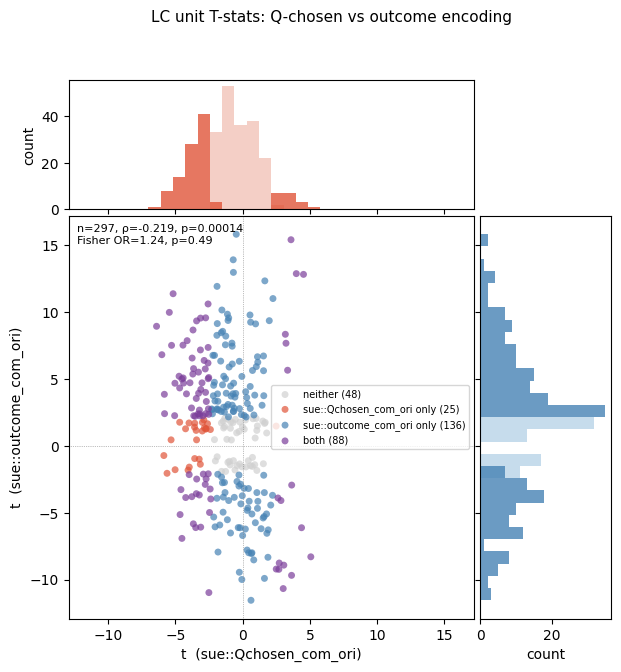

In [73]:
# Compare: Q-chosen vs outcome encoding (Sue internal)
merged_qch_out = reg.compare(
    "sue::Qchosen_com_ori",
    "sue::outcome_com_ori",
    title="LC unit T-stats: Q-chosen vs outcome encoding",
)

In [38]:
# Screen: RT encoding (response window) against all Sue variables
screen_results = reg.screen("ols_rt_response", source="sue", top_n=15)
print("Top 15 Sue variables correlated with RT encoding (response window):")
print(screen_results.to_string(index=False))

Top 15 Sue variables correlated with RT encoding (response window):
                     entry  n       rho        p  abs_rho
     sue::response_hit_all 72 -0.522381 0.000003 0.522381
        sue::ratio_hit_all 72 -0.470738 0.000030 0.470738
         sue::Qchosen_l_mc 85  0.335001 0.001725 0.335001
        sue::Qchosen_l_ori 85  0.335001 0.001725 0.335001
     sue::baseline_hit_all 72  0.326806 0.005081 0.326806
       sue::Qchosen_com_mc 85  0.291773 0.006740 0.291773
      sue::Qchosen_com_ori 85  0.291773 0.006740 0.291773
      sue::Qchosen_indi_mc 85  0.286496 0.007855 0.286496
     sue::Qchosen_indi_ori 85  0.286496 0.007855 0.286496
        sue::ratio_svs_all 85  0.241040 0.026267 0.241040
     sue::response_svs_all 85  0.195544 0.072894 0.195544
         sue::outcome_e_mc 85 -0.172347 0.114735 0.172347
        sue::outcome_e_ori 85 -0.172347 0.114735 0.172347
        sue::ratio_svs_hit 85  0.161833 0.138951 0.161833
sue::outcome:ipsi_indi_ori 85  0.156713 0.152059 0.156713


In [39]:
# Screen: RT encoding (baseline window) against all Sue variables
screen_bl = reg.screen("ols_rt_baseline", source="sue", top_n=15)
print("\nTop 15 Sue variables correlated with RT encoding (baseline window):")
print(screen_bl.to_string(index=False))


Top 15 Sue variables correlated with RT encoding (baseline window):
                      entry  n       rho        p  abs_rho
      sue::baseline_hit_all 72 -0.361535 0.001807 0.361535
          sue::outcome_l_mc 85 -0.280066 0.009431 0.280066
         sue::outcome_l_ori 85 -0.280066 0.009431 0.280066
  sue::outcome:ipsi_indi_mc 85 -0.213191 0.050112 0.213191
 sue::outcome:ipsi_indi_ori 85 -0.213191 0.050112 0.213191
        sue::Qchosen_com_mc 85 -0.209810 0.053952 0.209810
       sue::Qchosen_com_ori 85 -0.209810 0.053952 0.209810
     sue::outcome:ipsi_l_mc 85 -0.204280 0.060750 0.204280
    sue::outcome:ipsi_l_ori 85 -0.204280 0.060750 0.204280
      sue::Qchosen_indi_ori 85 -0.192202 0.078027 0.192202
       sue::Qchosen_indi_mc 85 -0.192202 0.078027 0.192202
      sue::baseline_amp_hit 85  0.187727 0.085348 0.187727
      sue::baseline_amp_all 85  0.181474 0.096480 0.181474
sue::baseline_Intercept_all 85  0.169533 0.120872 0.169533
      sue::response_amp_all 85  0.157866 0.149

Saved: /root/capsule/scratch/figures/poster/rt_response_summary.png, /root/capsule/scratch/figures/poster/rt_response_summary.svg


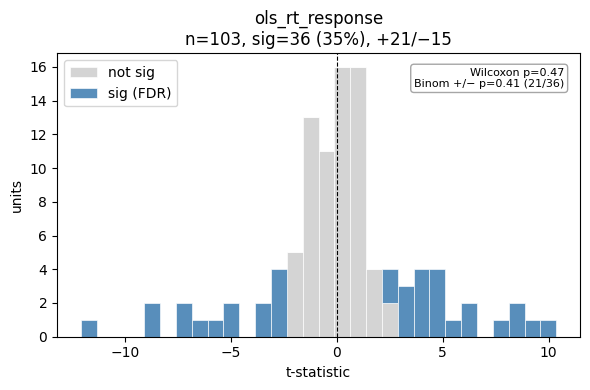

In [40]:
stats_rt = reg.summary(
    "ols_rt_response",
    save_path="/root/capsule/scratch/figures/poster/rt_response_summary",
)

Saved: /root/capsule/scratch/figures/poster/rt_baseline_summary.png, /root/capsule/scratch/figures/poster/rt_baseline_summary.svg


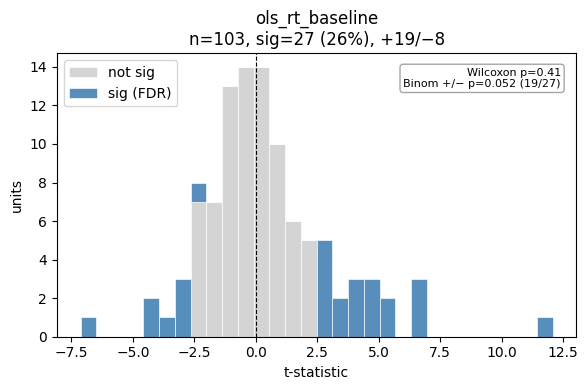

In [41]:
stats_rt = reg.summary(
    "ols_rt_baseline",
    save_path="/root/capsule/scratch/figures/poster/rt_baseline_summary",
)

Saved: /root/capsule/scratch/figures/poster/rt_response_vs_baseline_compare.png, /root/capsule/scratch/figures/poster/rt_response_vs_baseline_compare.svg


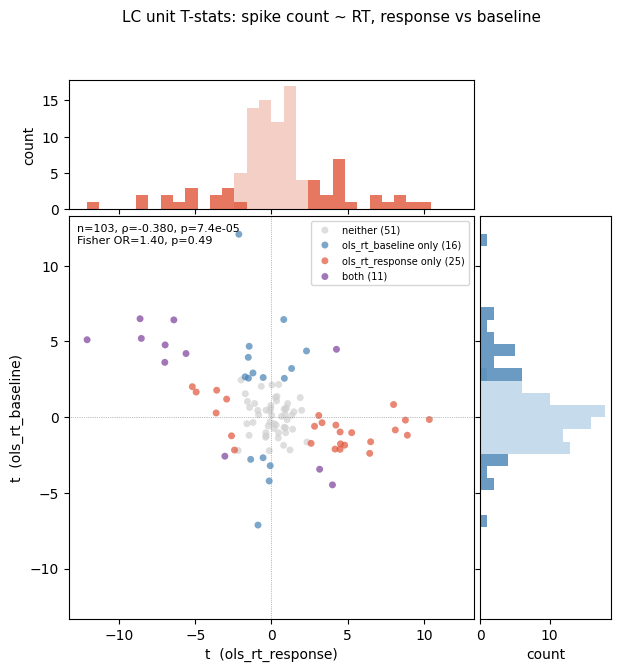

In [42]:
merged_rt_resp_bl = reg.compare(
    "ols_rt_response",
    "ols_rt_baseline",
    title="LC unit T-stats: spike count ~ RT, response vs baseline",
    save_path="/root/capsule/scratch/figures/poster/rt_response_vs_baseline_compare",
)

Saved: /root/capsule/scratch/figures/poster/rt_response_vs_respond_compare.png, /root/capsule/scratch/figures/poster/rt_response_vs_respond_compare.svg


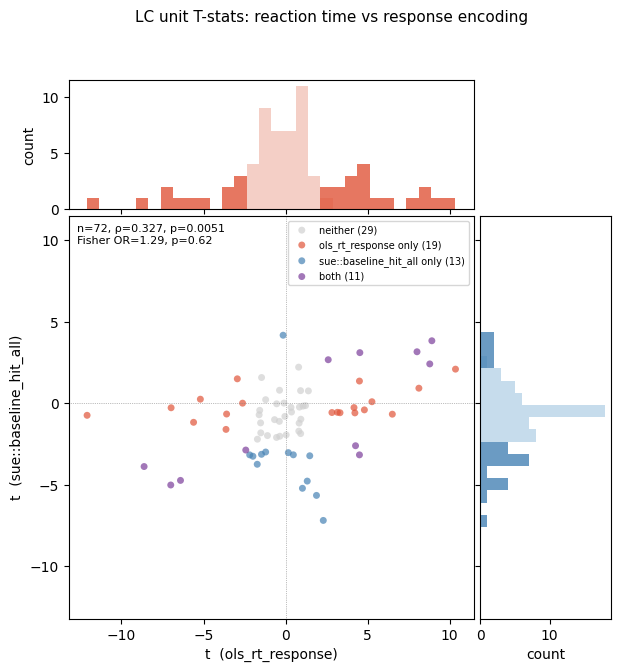

In [79]:
# Compare: spike_count ~ RT  vs  respond encoding
merged_outcome = reg.compare(
    "ols_rt_response",
    "sue::baseline_hit_all",
    title="LC unit T-stats: reaction time vs response encoding",
    save_path="/root/capsule/scratch/figures/poster/rt_response_vs_respond_compare",
)

Saved: /root/capsule/scratch/figures/poster/rt_baseline_vs_respond_compare.png, /root/capsule/scratch/figures/poster/rt_baseline_vs_respond_compare.svg


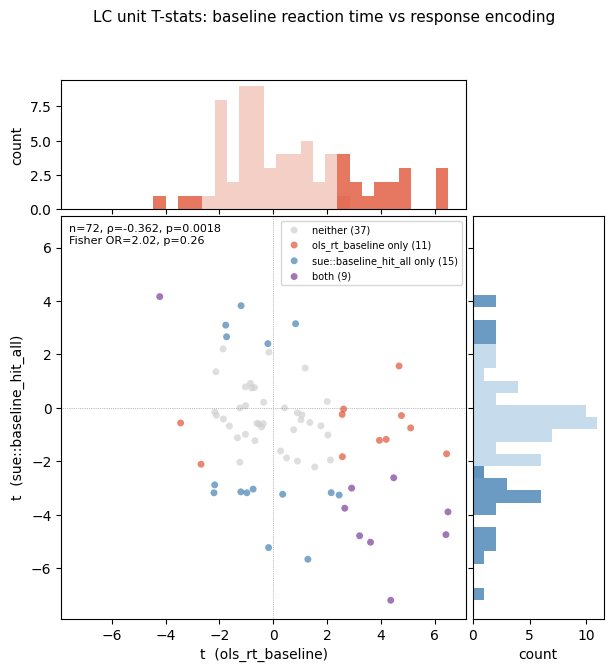

In [44]:
# Compare: spike_count ~ RT (baseline)  vs  respond encoding
merged_outcome = reg.compare(
    "ols_rt_baseline",
    "sue::baseline_hit_all",
    title="LC unit T-stats: baseline reaction time vs response encoding",
    save_path="/root/capsule/scratch/figures/poster/rt_baseline_vs_respond_compare",
)

Saved: /root/capsule/scratch/figures/poster/rt_response_vs_value_compare.png, /root/capsule/scratch/figures/poster/rt_response_vs_value_compare.svg


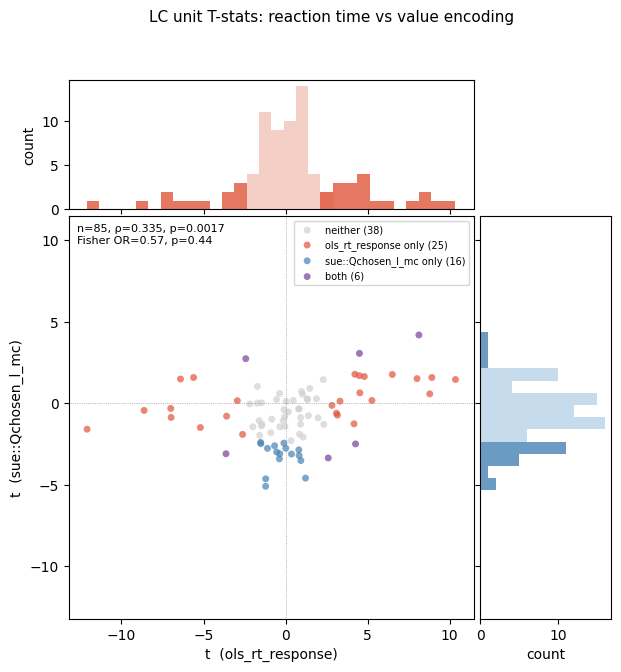

In [45]:
# Compare: spike_count ~ RT  vs  respond encoding
merged_outcome = reg.compare(
    "ols_rt_response",
    "sue::Qchosen_l_mc",
    title="LC unit T-stats: reaction time vs value encoding",
    save_path="/root/capsule/scratch/figures/poster/rt_response_vs_value_compare",
)



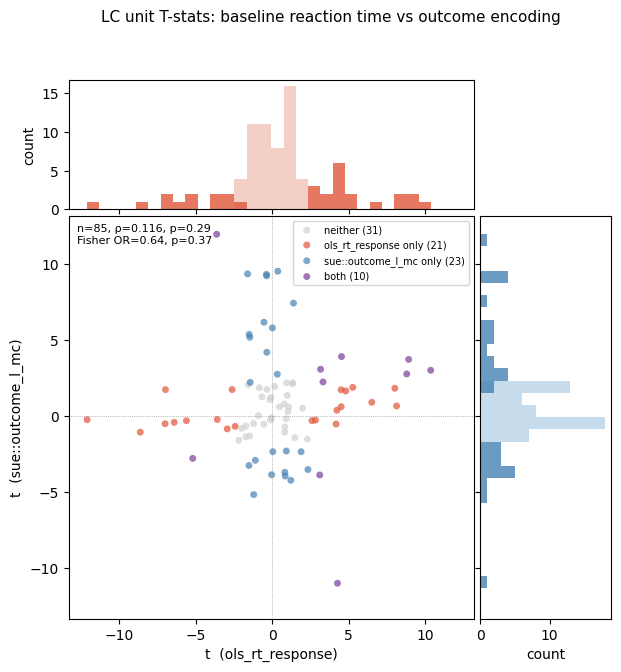

In [47]:
# Compare: spike_count ~ RT (baseline)  vs  respond encoding
merged_outcome = reg.compare(
    "ols_rt_response",
    "sue::outcome_l_mc",
    title="LC unit T-stats: baseline reaction time vs outcome encoding",
)

Saved: /root/capsule/scratch/figures/poster/rt_baseline_vs_outcome_compare.png, /root/capsule/scratch/figures/poster/rt_baseline_vs_outcome_compare.svg


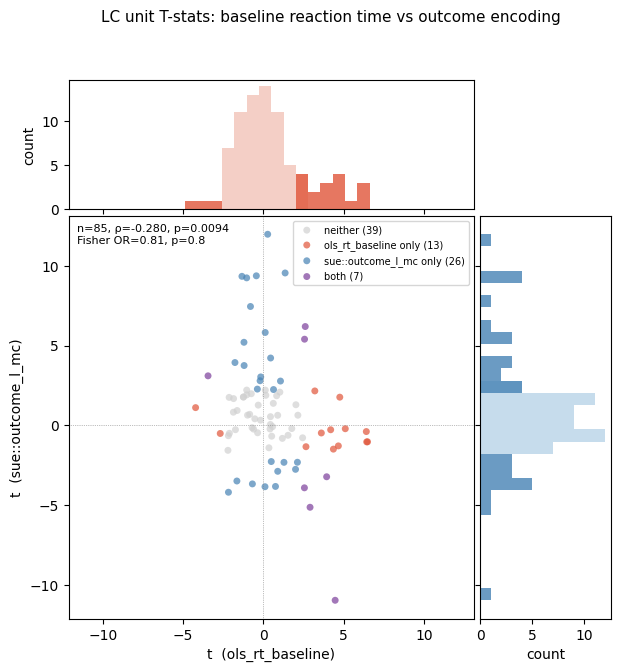

In [46]:
# Compare: spike_count ~ RT (baseline)  vs  respond encoding
merged_outcome = reg.compare(
    "ols_rt_baseline",
    "sue::outcome_l_mc",
    title="LC unit T-stats: baseline reaction time vs outcome encoding",
    save_path="/root/capsule/scratch/figures/poster/rt_baseline_vs_outcome_compare",
)

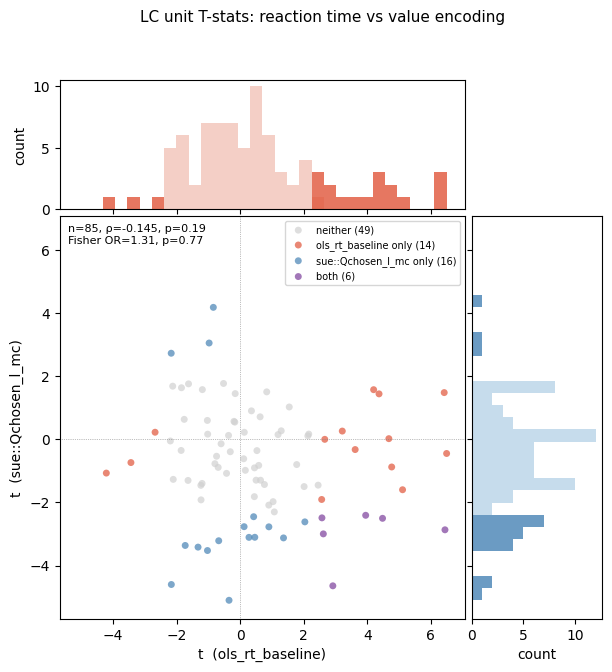

In [48]:
# Compare: spike_count ~ RT  vs  respond encoding
merged_outcome = reg.compare(
    "ols_rt_baseline",
    "sue::Qchosen_l_mc",
    title="LC unit T-stats: reaction time vs value encoding",
)

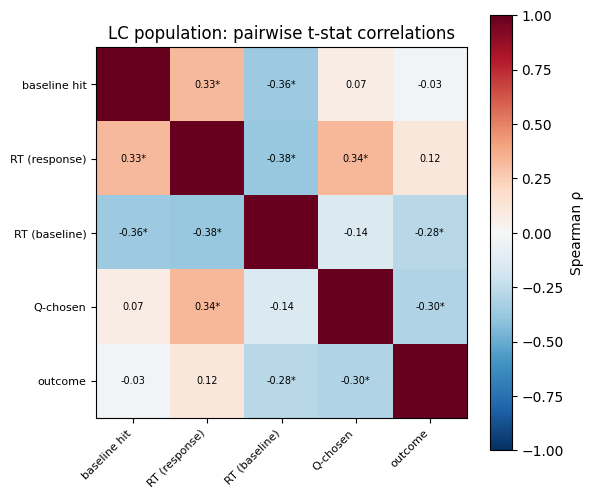

In [ ]:
rho_df = reg.heatmap(
    entries=[
        "ols_rt_response", "ols_rt_baseline",
        "sue::Qchosen_l_mc", "sue::outcome_l_mc",
        "sue::baseline_hit_all",
    ],
    labels={
        "ols_rt_response":      "RT (response)",
        "ols_rt_baseline":      "RT (baseline)",
        "sue::Qchosen_l_mc":   "Q-chosen (Value)",
        "sue::outcome_l_mc":   "Outcome (Reward)",
        "sue::baseline_hit_all":    "Respond vs Ignore (baseline)",
    },
    title="LC population: pairwise t-stat correlations",
)

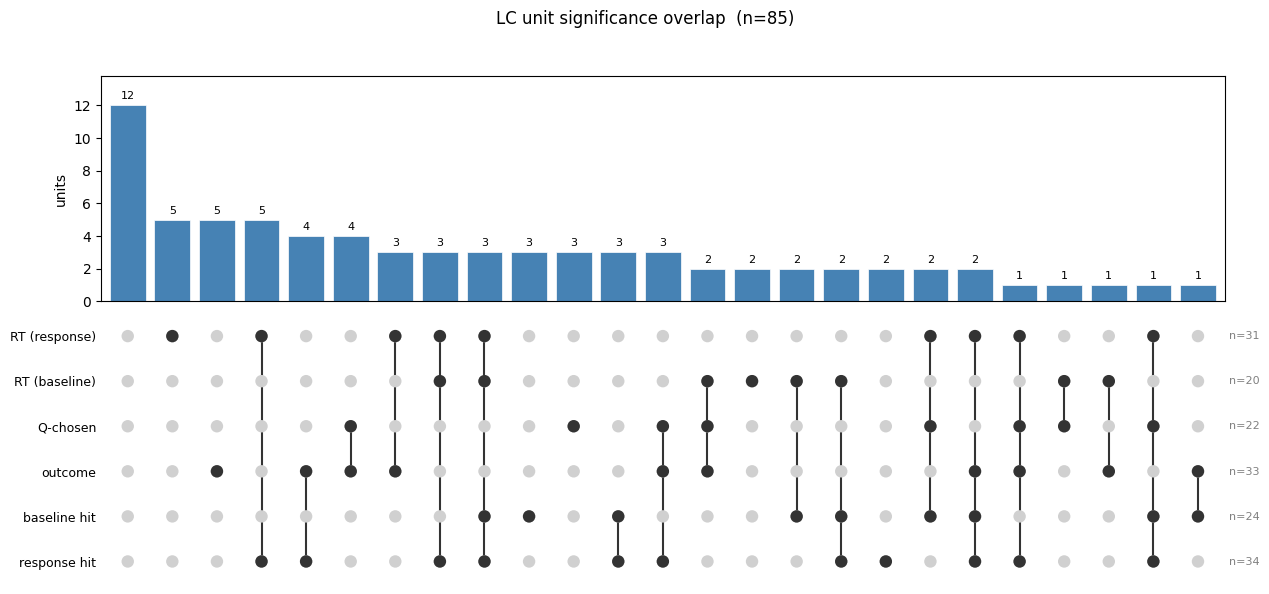

In [75]:
membership = reg.upset(
    entries=[
        "ols_rt_response", "ols_rt_baseline",
        "sue::Qchosen_l_mc", "sue::outcome_l_mc",
        "sue::baseline_hit_all", "sue::response_hit_all"
    ],
    labels={
        "ols_rt_response":       "RT (response)",
        "ols_rt_baseline":       "RT (baseline)",
        "sue::Qchosen_l_mc":     "Q-chosen",
        "sue::outcome_l_mc":     "outcome",
        "sue::baseline_hit_all": "baseline hit",
        "sue::response_hit_all": "response hit",
    },
    title="LC unit significance overlap",
)

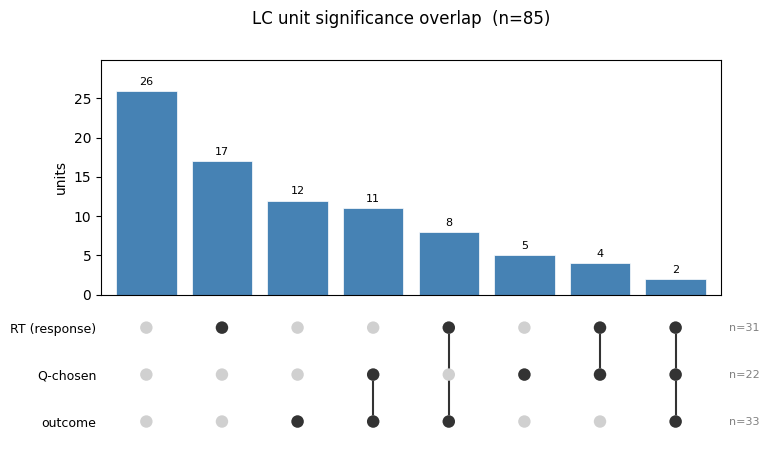

In [78]:
membership = reg.upset(
    entries=[
        "ols_rt_response",
        "sue::Qchosen_l_mc", "sue::outcome_l_mc"
    ],
    labels={
        "ols_rt_response":       "RT (response)",
        "sue::Qchosen_l_mc":     "Q-chosen",
        "sue::outcome_l_mc":     "outcome",
    },
    title="LC unit significance overlap",
)

In [69]:
import importlib
import per_unit_stats_registry
importlib.reload(per_unit_stats_registry)
from per_unit_stats_registry import PerUnitStatsRegistry